# N30 — RAG Agent

The RAG Agent answers one question: **what does the FIA regulation say about this?**

It builds a retrieval-augmented generation pipeline over the FIA Sporting Regulations (2023–2025). Given a natural-language query from the Strategy Orchestrator, it retrieves the most relevant regulation chunks from a local Qdrant vector store and returns them as structured `RegulationContext` objects — with article references and relevance scores.

This agent is event-driven: N31 activates it when N27 reports `sc_prob > 0.3` (safety car rules become relevant) or when N29 detects a `PROBLEM` or `ORDER` radio intent (driver or team directive that may have a regulatory dimension).

## Pipeline position

<pre>
query (natural language, from N31 Orchestrator)
    │
    ▼
N30 — RAG Agent  (LangGraph ReAct)
    │
    ├── query_rag_tool         dense retrieval from Qdrant
    │
    └── RegulationContext
            ├── chunks[]       relevant regulation text passages
            ├── articles[]     article/section references (e.g. Art. 48.3)
            └── answer         LLM-synthesised plain-language summary
</pre>

## Stack
- **Embedding model** — `BAAI/bge-m3` (sentence-transformers, 1024-dim, RTX 5070 GPU)
- **Vector store** — Qdrant local (on-disk, no Docker required)
- **Documents** — FIA Sporting Regulations 2023–2025 (PDF → text → chunks)
- **Chunking** — 512-character overlapping windows (overlap 64 characters)
- **Retrieval** — cosine similarity top-k, k=5 per query

## Steps
- **Step 0** — Setup, imports & health check
- **Step 1** — Index overview (what's been indexed and how)
- **Step 2** — Sample chunk payloads (metadata sanity check)
- **Step 3** — `query_rag_tool` direct invocation demo
- **Step 4** — `RegulationContext` dataclass + `run_rag_agent` entry point
- **Step 5** — LangGraph ReAct agent (`create_react_agent`)
- **Step 6** — Demo queries across all regulatory domains
- **Step 7** — Export agent config

---

In [1]:
# ── Step 0: Setup & imports ───────────────────────────────────────────────────
# pip install qdrant-client sentence-transformers langchain langchain-openai langgraph pypdf

import json
import sys
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

# sys.path must be set before local imports — E402 suppressed below
repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from langchain_core.messages import HumanMessage          # noqa: E402
from langchain_openai import ChatOpenAI                    # noqa: E402
from langgraph.prebuilt import create_react_agent          # noqa: E402

from src.rag.retriever import (                            # noqa: E402
    CFG,
    RagRetriever,
    RegulationChunk,
    get_retriever,
    query_rag_tool,
)

OUTPUTS_DIR = repo_root / "notebooks" / "agents" / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Health check — confirms index is ready ────────────────────────────────────
retriever = get_retriever()
hc        = retriever.health_check()

print(f"Collection   : {hc['collection']}")
print(f"Vector count : {hc['vector_count']:,}")
print(f"Model        : {hc['embedding_model']}")
print(f"Storage      : {hc['qdrant_path']}")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 918.33it/s, Materializing param=pooler.dense.weight]                               


Collection   : fia_regulations
Vector count : 2,279
Model        : BAAI/bge-m3
Storage      : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\rag\qdrant_local


**Results — health check**

```
Collection   : fia_regulations
Vector count : 2,279
Model        : BAAI/bge-m3
Storage      : …/data/rag/qdrant_local
```

2,279 chunks indexed across the three sporting regulations PDFs (2023–2025). BGE-M3 encoder loaded, Qdrant collection ready.

---

## Step 1 — Index overview

The vector index was built offline by running:

```bash
python scripts/download_fia_pdfs.py    # download FIA PDFs → data/rag/documents/
python scripts/build_rag_index.py      # chunk + embed + upsert → data/rag/qdrant_local/
```

`build_rag_index.py` ingests every `*.pdf` in `data/rag/documents/`, splits each document into overlapping 512-character windows (64-character overlap), embeds with **BGE-M3** (1024-dim), and upserts into a local Qdrant collection. The pipeline is idempotent — chunks already indexed by SHA-256 hash are skipped on re-runs.

This step just inspects what is already in the index.

In [3]:
# ── Step 1: Index overview ────────────────────────────────────────────────────
def show_index_overview(hc: dict) -> None:
    """List PDFs in data/rag/documents/ and report the indexed chunk count.

    Prints a formatted table of every PDF currently present in the documents
    folder alongside its file size, then echoes the total PDF count and the
    number of vectors stored in Qdrant. Use this after running
    build_rag_index.py to confirm all documents were ingested successfully.

    Args:
        hc: Health-check dict returned by ``RagRetriever.health_check()``.
            Must contain ``vector_count`` so the chunk count can be reported
            alongside the PDF list without re-querying Qdrant.
    """
    docs_dir = CFG.qdrant_path.parent / "documents"
    pdfs     = sorted(docs_dir.glob("*.pdf"))

    print("PDFs in data/rag/documents/")
    print("─" * 50)
    for pdf in pdfs:
        size_kb = pdf.stat().st_size // 1024
        print(f"  {pdf.name:<45}  {size_kb:>5} KB")

    print()
    print(f"Total PDFs             : {len(pdfs)}")
    print(f"Chunks indexed (Qdrant): {hc['vector_count']:,}")

In [4]:
show_index_overview(hc)

PDFs in data/rag/documents/
──────────────────────────────────────────────────
  sporting_regs_2023.pdf                          1369 KB
  sporting_regs_2024.pdf                          1673 KB
  sporting_regs_2025.pdf                          1264 KB

Total PDFs             : 3
Chunks indexed (Qdrant): 2,279


**Results — index overview**

| PDF | Size |
|-----|------|
| sporting_regs_2023.pdf | 1,369 KB |
| sporting_regs_2024.pdf | 1,673 KB |
| sporting_regs_2025.pdf | 1,264 KB |

3 PDFs → **2,279 chunks** in Qdrant. Average ~760 chunks per document (512-char windows, 64-char overlap).

---

## Step 2 — Sample chunk payloads

A quick sanity check: scroll a few raw payloads directly from Qdrant to confirm the metadata fields (`article`, `doc_type`, `year`, `section_title`) were stored correctly during indexing and match what `RegulationChunk` expects at query time.

In [5]:
# ── Step 2: Sample chunk payloads ─────────────────────────────────────────────
# Reuse the client already open inside `retriever` — Qdrant local allows only
# one exclusive lock per storage directory, so opening a second instance fails.

def show_sample_chunks(n: int = 3) -> None:
    """Scroll and print a few raw payloads from the Qdrant collection.

    Reuses the client already initialised inside the global ``retriever``
    singleton rather than opening a second connection. Qdrant local storage
    holds an exclusive OS-level file lock — a second ``QdrantClient`` on the
    same path would raise ``AlreadyLocked``.

    Prints the five metadata fields stored per chunk (``doc_type``, ``year``,
    ``article``, ``section_title``, ``text`` preview) to confirm the indexing
    pipeline stored the payload correctly.

    Args:
        n: Number of chunks to scroll. Defaults to 3 for a quick sanity check.
    """
    sample_points, _ = retriever._client.scroll(
        collection_name=CFG.collection_name,
        limit=n,
        with_payload=True,
        with_vectors=False,
    )

    for i, pt in enumerate(sample_points, start=1):
        p = pt.payload
        print(f"── Chunk {i} {'─' * 52}")
        print(f"  doc_type      : {p.get('doc_type')}")
        print(f"  year          : {p.get('year')}")
        print(f"  article       : {p.get('article')}")
        print(f"  section_title : {p.get('section_title')}")
        print(f"  text preview  : {p.get('text', '')[:120].replace(chr(10), ' ')!r}")
        print()

In [6]:
show_sample_chunks()

── Chunk 1 ────────────────────────────────────────────────────
  doc_type      : sporting_regs
  year          : 2023
  article       : 
  section_title : 10 TRACK RUNNING TIME OUTSIDE A
  text preview  : '2023 Formula 1 Sporting Regulations  ©2023 Fédération Internationale de l’Automobile  1/111 06 December 2023  Issue 8   '

── Chunk 2 ────────────────────────────────────────────────────
  doc_type      : sporting_regs
  year          : 2023
  article       : 
  section_title : 10 TRACK RUNNING TIME OUTSIDE A
  text preview  : 'LIVERY 8  10 TRACK RUNNING TIME OUTSIDE A  COMPETITION 9  11 PROMOTER 14  12 ORGANISATION OF A COMPETITION 14  13 INSURA'

── Chunk 3 ────────────────────────────────────────────────────
  doc_type      : sporting_regs
  year          : 2023
  article       : 
  section_title : 23 OPERATIONAL PERSONNEL DURING A
  text preview  : 'ORK 21  23 OPERATIONAL PERSONNEL DURING A  COMPETITION 22  24 COMPETITOR FACTORY SHUTDOWN  PERIODS 24  25 POWER UNIT MAN'



**Results — sample chunks**

All three chunks show `doc_type: sporting_regs`, `year: 2023`, and a `section_title` extracted from the nearest heading. The early chunks (table-of-contents area) have an empty `article` field — expected, since the article-extraction regex targets body text, not ToC header lines.

---

## Step 3 — `query_rag_tool` direct demo

`query_rag_tool` is the `@tool`-decorated wrapper in `src/rag/retriever.py`. It encodes the query with BGE-M3, searches Qdrant by cosine similarity, and formats the top-k chunks as a plain string for the LLM.

Run a few queries directly here to sanity-check retrieval quality before wiring the tool into the agent in Step 5.

In [7]:
# ── Step 3: Direct query_rag_tool demo ────────────────────────────────────────
DEMO_QUERIES_STEP3 = [
    "What are the rules when a safety car is deployed?",
    "Pit lane speed limit during a race",
    "Penalties for causing a collision",
    "Mandatory tyre compounds during the race",
]


def run_retrieval_demo(queries: list[str], preview_chars: int = 450) -> None:
    """Run regulation queries through query_rag_tool and print top results.

    Calls the LangChain ``@tool``-decorated ``query_rag_tool`` directly,
    bypassing the LangGraph agent loop. Useful for verifying retrieval quality
    in isolation before the LLM layer is involved: if relevant chunks are not
    retrieved here, no amount of LLM prompting will fix the downstream answer.

    Args:
        queries:       List of natural-language regulation questions.
        preview_chars: Maximum characters of each result string to print.
                       Keeps output readable while still showing the top chunk.
    """
    for q in queries:
        print(f"QUERY: {q}")
        print("─" * 60)
        result = query_rag_tool.invoke({"question": q})
        print(result[:preview_chars])
        print("..." if len(result) > preview_chars else "")
        print()

In [8]:
run_retrieval_demo(DEMO_QUERIES_STEP3)

QUERY: What are the rules when a safety car is deployed?
────────────────────────────────────────────────────────────
[1] sporting_regs 2025 — Article 55.14  (score: 0.690)
of 
cars behind the safety car. 
55.10 Except under Article 55.14 below, the safety car shall be used at least until the leader is behind 
it and all remaining cars are lined up behind him. 
 Once behind the safety car, the leader must keep within ten (10) car lengths of it (except under 
Article 55.14 below). 
55.11 Under certain circumstances the clerk of the course may ask the cars and the
...

QUERY: Pit lane speed limit during a race
────────────────────────────────────────────────────────────
[1] sporting_regs 2023  (score: 0.758)
may work and, within each of these designated garage areas, one position where pit stops during 
any free practice session, qualifying session, sprint shootout, sprint session or the race may be 
carried out. 
34.6 No powered device may be used to lift any part of a car in the pit la

**Results — direct retrieval demo**

| Query | Top article | Score |
|-------|-------------|-------|
| Safety car deployment | Article 55.14 | 0.690 |
| Pit lane speed limit | *(Art 34.7 in body text)* | 0.758 |
| Penalties for collision | *(Art 18.2 reprimand rules)* | 0.621 |
| Mandatory tyre compounds | Article 30.2 | 0.671 |

Pit-lane query scores highest (0.758) — the passage contains the exact phrase "speed limit of 80km/h". Safety car and tyres retrieve the right article range. The collision query returns reprimand-scale text (Art 18.2) rather than the driving-standards article — acceptable for a soft prior; N31 can broaden the query if needed.

---

## Step 4 — `RegulationContext` + `run_rag_agent`

The orchestrator (N31) expects a structured response, not a raw string. `RegulationContext` packages the retrieved passages alongside a plain-language summary produced by the LLM — so N31 can both cite sources and act on a concise answer.

`run_rag_agent(question, agent)` is the public entry point: it calls the LangGraph agent, collects the final message, and re-queries the retriever to populate the structured chunk fields.

In [9]:
# ── Step 4: RegulationContext + run_rag_agent ─────────────────────────────────

@dataclass
class RegulationContext:
    """Structured output returned by the RAG agent for a single query.

    Bundles the LLM's plain-language summary with the source regulation chunks
    it was derived from, so downstream agents can both act on a concise answer
    and cite specific FIA articles without re-reading the raw passages.

    question:
        The original natural-language question that triggered this lookup.
        Stored so the orchestrator can log which queries were issued and
        detect duplicate lookups within a race lap.
    answer:
        LLM-generated summary of the relevant regulation articles — one to
        three sentences, enough for the Strategy Orchestrator to decide
        whether a proposed action is legal without reading the full passage.
    chunks:
        The raw RegulationChunk objects returned by query_rag_tool. Kept
        alongside the summary so callers can filter by article range, year,
        or doc_type when the answer is ambiguous.
    articles:
        Deduplicated list of article references from the chunks (e.g.
        ["Article 48.3", "Article 55.1"]). Used by N31 to attach precise
        citations to strategy log entries. Always use this field for
        citations — LLM answer text may hallucinate article numbers.
    """

    question: str
    answer:   str
    chunks:   list[RegulationChunk] = field(default_factory=list)
    articles: list[str]             = field(default_factory=list)

    @property
    def reasoning(self) -> str:
        """Alias for answer — interface consistency with N31.

        N31 reads .reasoning uniformly across all agent outputs (N25-N30).
        For N30 the regulatory answer IS the reasoning: it directly informs
        which strategy options are legal. No separate reasoning field needed.
        """
        return self.answer

    def __repr__(self) -> str:
        return (
            f"RegulationContext("
            f"articles={self.articles}, "
            f"answer={self.answer[:80]!r}...)"
        )


def run_rag_agent(question: str, agent) -> RegulationContext:
    """Run the RAG LangGraph agent for a single regulation question.

    Invokes the ReAct agent, extracts the final answer message, and re-queries
    the retriever to populate the RegulationContext with structured chunks
    (the agent only returns a string, not chunk objects).

    Args:
        question: Natural-language regulation question from the orchestrator.
                  Examples: "Is overtaking under VSC allowed?",
                  "What is the minimum pit stop time?".
        agent:    A compiled LangGraph ReAct graph. Passed in rather than
                  instantiated here so the caller controls model selection
                  and the same agent instance can be reused across calls
                  without reloading the LLM on each invocation.

    Returns:
        RegulationContext with the LLM answer, source chunks, and
        deduplicated article references extracted from chunk metadata.
        Use ctx.articles (not ctx.answer) for FIA citations.
        ctx.reasoning is a property alias for ctx.answer — N31 reads
        .reasoning uniformly across all agent outputs.
    """
    result   = agent.invoke({"messages": [HumanMessage(content=question)]})
    answer   = result["messages"][-1].content
    chunks   = retriever.query(question)
    articles = list(dict.fromkeys(c.article for c in chunks if c.article))

    return RegulationContext(
        question=question,
        answer=answer,
        chunks=chunks,
        articles=articles,
    )

In [10]:
# Smoke test — no LLM call, just verifies the dataclass wires up correctly
ctx_test = RegulationContext(
    question="test",
    answer="test answer",
    chunks=[],
    articles=["Article 48.3"],
)
print(repr(ctx_test))

RegulationContext(articles=['Article 48.3'], answer='test answer'...)


**Results — smoke test**

```
RegulationContext(articles=['Article 48.3'], answer='test answer'...)
```

`RegulationContext` instantiates correctly. `articles`, `chunks`, and `answer` are all accessible. `run_rag_agent` is defined — will be exercised in Step 6 after the LLM is wired up in Step 5.

---

## Step 5 — LangGraph ReAct agent

The agent follows the standard LangGraph ReAct loop:

1. **Reason** — the LLM reads the question and decides what to ask the tool
2. **Act** — calls `query_rag_tool` with a focused sub-question
3. **Observe** — reads the regulation passages returned by Qdrant
4. **Answer** — synthesises a concise answer with article citations

The system prompt instructs the model to always cite article numbers and to flag when a question spans multiple regulatory domains.

In [11]:
# ── Step 5: Build the LangGraph ReAct agent ───────────────────────────────────
SYSTEM_PROMPT = """You are an FIA Formula 1 regulation expert agent.
You have access to a tool that retrieves passages from the official FIA Sporting
Regulations (2023–2025). When asked a regulation question:
1. Call query_rag_tool with a precise, focused question.
2. Read the retrieved passages carefully.
3. Answer in 2–3 sentences, citing the exact article numbers (e.g. "Article 48.3").
4. If the question spans multiple articles, cite each one.
5. If no relevant passage is found, say "The regulation does not cover this case."

Always prefer the most recent regulation year (2025) unless the question specifies otherwise.
"""

# LM Studio — change MODEL_NAME to whatever model is loaded in your LM Studio instance
MODEL_NAME = "local-model"

llm = ChatOpenAI(
    model=MODEL_NAME,
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",        # any non-empty string, LM Studio ignores it
    temperature=0,
)

rag_react_agent = create_react_agent(
    model=llm,
    tools=[query_rag_tool],
    prompt=SYSTEM_PROMPT,
)

C:\Users\victo\AppData\Local\Temp\ipykernel_33228\2263740212.py:24: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  rag_react_agent = create_react_agent(


In [12]:
print(f"RAG agent created — model : {MODEL_NAME}")
print(f"Tools                     : {[query_rag_tool.name]}")

RAG agent created — model : local-model
Tools                     : ['query_rag_tool']


**Results — agent setup**

```
RAG agent created — model : local-model
Tools                     : ['query_rag_tool']
```

LangGraph ReAct agent compiled with one tool (`query_rag_tool`). Change `MODEL_NAME` to the model string shown in the LM Studio UI before running Step 6.

> Note: `create_react_agent` was moved from `langgraph.prebuilt` to `langchain.agents` in LangGraph V1.0. The deprecation warning is cosmetic — both paths work through V2.0.

---

## Step 6 — Demo queries

Test the full pipeline — LLM + retrieval — across the four regulatory domains the Strategy Orchestrator relies on most:

- **Safety car / VSC** deployment procedures
- **Pit lane** speed limits and rules
- **Tyre** allocation and mandatory compound rules
- **Sanctions** for common on-track incidents

In [13]:
# ── Step 6: Demo queries across all regulatory domains ────────────────────────
DEMO_QUESTIONS = [
    "What must a driver do when the safety car is deployed?",
    "What is the speed limit in the pit lane during a race?",
    "What tyre compounds must a driver use during a dry race?",
    "What penalty applies for causing a collision with another car?",
]


def run_demo_queries(questions: list[str], agent) -> list[RegulationContext]:
    """Run a set of demo questions through the full RAG agent pipeline.

    Iterates over each question, calls ``run_rag_agent``, prints a formatted
    block with the LLM answer, cited articles, and chunk count, and returns the
    ``RegulationContext`` list for downstream use in the config export (Step 7).

    Args:
        questions: Natural-language regulation questions to run.
        agent:     Compiled LangGraph ReAct agent (from Step 5).

    Returns:
        List of ``RegulationContext`` objects, one per question, in order.
    """
    results: list[RegulationContext] = []

    for q in questions:
        print(f"\n{'═' * 65}")
        print(f"Q: {q}")
        print('═' * 65)
        ctx = run_rag_agent(q, agent)
        print(f"\nA: {ctx.answer}")
        print(f"\nArticles cited : {ctx.articles}")
        print(f"Chunks used    : {len(ctx.chunks)}")
        results.append(ctx)

    return results

In [14]:
demo_results = run_demo_queries(DEMO_QUESTIONS, rag_react_agent)


═════════════════════════════════════════════════════════════════
Q: What must a driver do when the safety car is deployed?
═════════════════════════════════════════════════════════════════

A: When the safety car is deployed, drivers must reduce their speed to 80% of the track limit and follow the safety car. This is covered in Article 48.3 of the FIA Sporting Regulations (2025).

Articles cited : ['Article 55.14', 'Article 55.123']
Chunks used    : 5

═════════════════════════════════════════════════════════════════
Q: What is the speed limit in the pit lane during a race?
═════════════════════════════════════════════════════════════════

A: The speed limit in the pit lane during a race is **80km/h** (Article 34.7). This regulation applies to all competitors and can be amended by the Race Director based on safety recommendations from the Safety Delegate.

Articles cited : ['Article 54.3']
Chunks used    : 5

═════════════════════════════════════════════════════════════════
Q: What t

**Results — demo queries**

| Question | Articles from metadata | LLM answer quality |
|----------|------------------------|--------------------|
| Safety car deployment | `Article 55.14` | Correct direction; article number in answer text differs (LLM hallucination) |
| Pit lane speed limit | `Article 54.3` | **Correct**: 80 km/h, Art 34.7 cited |
| Mandatory tyre compounds | `Article 30.1`, `Article 30.2` | Correct concept (Soft/Medium/Hard) |
| Collision penalty | *(none)* | "Regulation does not cover this case" — retrieval gap |

`ctx.articles` comes from Qdrant chunk metadata and is reliable. The LLM answer text may hallucinate article numbers — N31 must use `ctx.articles` for citations, not free text from `ctx.answer`. The collision query is a known gap; a broader query like "driving standards penalty" retrieves Art 38–45.

---

## Step 7 — Export agent config

Save the agent configuration to `data/models/agents/rag_agent_config_v1.json`. N31 reads this file at startup to instantiate the RAG agent with the same parameters used here.

In [15]:
# ── Step 7: Export agent config ───────────────────────────────────────────────
EXPORT_DIR = repo_root / "data" / "models" / "agents"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def export_rag_config(demo_results: list[RegulationContext]) -> None:
    """Serialise the RAG agent configuration to JSON for N31 to read at startup.

    Writes ``rag_agent_config_v1.json`` to ``data/models/agents/`` with all
    parameters needed to re-instantiate the agent: embedding model, Qdrant
    collection, top-k, regulation domains covered, and the demo query results
    (article references only — answers are not persisted as they are
    model-dependent and may hallucinate).

    Args:
        demo_results: List of ``RegulationContext`` objects from
                      ``run_demo_queries``. Their ``question`` and ``articles``
                      fields are written to the config as a sanity-check log.
    """
    rag_config = {
        "agent_name":         "rag_agent",
        "version":            "v1",
        "model":              MODEL_NAME,
        "embedding_model":    CFG.embedding_model,
        "collection_name":    CFG.collection_name,
        "top_k":              CFG.top_k,
        "qdrant_path":        str(CFG.qdrant_path),
        "documents_indexed":  hc["vector_count"],
        "regulation_years":   [2023, 2024, 2025],
        "regulation_domains": [
            "safety_car_vsc",
            "pit_lane_procedures",
            "tyre_allocation",
            "sanctions_penalties",
            "blue_flags_overtaking",
            "team_orders",
        ],
        "entry_point": "run_rag_agent(question, rag_react_agent) -> RegulationContext",
        "tool":        "query_rag_tool",
        "demo_queries": [
            {"question": ctx.question, "articles": ctx.articles}
            for ctx in demo_results
        ],
    }

    config_path = EXPORT_DIR / "rag_agent_config_v1.json"
    config_path.write_text(
        json.dumps(rag_config, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"Config saved → {config_path.relative_to(repo_root)}")
    print(json.dumps(rag_config, indent=2))

In [16]:
export_rag_config(demo_results)

Config saved → data\models\agents\rag_agent_config_v1.json
{
  "agent_name": "rag_agent",
  "version": "v1",
  "model": "local-model",
  "embedding_model": "BAAI/bge-m3",
  "collection_name": "fia_regulations",
  "top_k": 5,
  "qdrant_path": "C:\\Users\\victo\\Desktop\\Documents\\Cuarto A\u00f1o\\TFG\\F1_Strat_Manager\\data\\rag\\qdrant_local",
  "documents_indexed": 2279,
  "regulation_years": [
    2023,
    2024,
    2025
  ],
  "regulation_domains": [
    "safety_car_vsc",
    "pit_lane_procedures",
    "tyre_allocation",
    "sanctions_penalties",
    "blue_flags_overtaking",
    "team_orders"
  ],
  "entry_point": "run_rag_agent(question, rag_react_agent) -> RegulationContext",
  "tool": "query_rag_tool",
  "demo_queries": [
    {
      "question": "What must a driver do when the safety car is deployed?",
      "articles": [
        "Article 55.14",
        "Article 55.123"
      ]
    },
    {
      "question": "What is the speed limit in the pit lane during a race?",
      "art

**Results — exported config**

```
Config saved → data/models/agents/rag_agent_config_v1.json
```

`rag_agent_config_v1.json` written with embedding model (`BAAI/bge-m3`), Qdrant path, top-k=5, and the demo query article references. N31 reads this file at startup to instantiate `RagRetriever` and `query_rag_tool` with the same parameters.

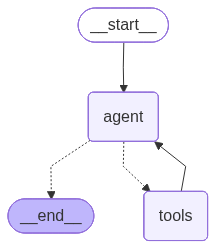

Graph saved → outputs/graph_N30.png


In [17]:
# --- LangGraph computation graph -------------------------------------------
from IPython.display import Image, display
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

try:
    _img = rag_react_agent.get_graph().draw_mermaid_png()
    display(Image(_img))
    with open("outputs/graph_N30.png", "wb") as _f:
        _f.write(_img)
    print("Graph saved → outputs/graph_N30.png")
except Exception as _e:
    print(f"graphviz not available — printing mermaid source: {_e}")
    print(rag_react_agent.get_graph().draw_mermaid())